In [15]:
import numpy as np
from pathlib import Path
import sys
import os
import scipy
from scipy.stats import norm
import matplotlib.pyplot as plt

In [16]:
# load data
# sim_id = 92
sim_id = 0

save_path = Path('../data') / 'results'
discrims = np.load(Path(save_path) / f'sim_{sim_id:04d}_1k_trials_full_discrim.npy')
curvatures = np.load(Path(save_path) / f'sim_{sim_id:04d}_1k_trials_full_curvs.npy')

mat2 = scipy.io.loadmat(Path('../data') / 'bin_sizes_all.mat')
bin_sizes_all = mat2['bin_sizes_all'][0][12:-2]

# load corresponding sample neural responses
data_path = Path('../data')
f_name = f'sim_{sim_id:04d}.mat' # slow sensory-driven time scale
S = scipy.io.loadmat(Path(data_path) / f_name)['S']
S_list = [S[0, i] for i in range(S.shape[1])]  # convert to list of structs

In [17]:
# convert bin size to number of bins
dt = S_list[0]['dt'][0, 0]
T = S_list[0]['T'][0, 0]
n_timepoints = T / dt
n_bins = np.zeros(len(bin_sizes_all))

for j, bin_size in enumerate(bin_sizes_all):
    bin_length = int((bin_size / dt.item()))
    n_bins[j] = int((n_timepoints // bin_length))
    # bin_length = int((bin_size / dt))
    # n_bins[j] = int((n_timepoints // bin_length))

print(bin_sizes_all)
print(n_bins)

[0.05  0.055 0.088 0.1   0.11  0.2   0.22  0.275 0.44  0.55 ]
[44. 40. 25. 22. 20. 11. 10.  8.  5.  4.]


In [18]:
# get population sizes
# n_neurons = np.zeros(len(S_list))
# for ipop in range(len(S_list)):
#     n_neurons[ipop] = S_list[ipop]['n_neuron'][0,0]
n_neurons = [2, 4, 8, 10, 20, 40, 50, 100]
# chance = 1 / n_bins

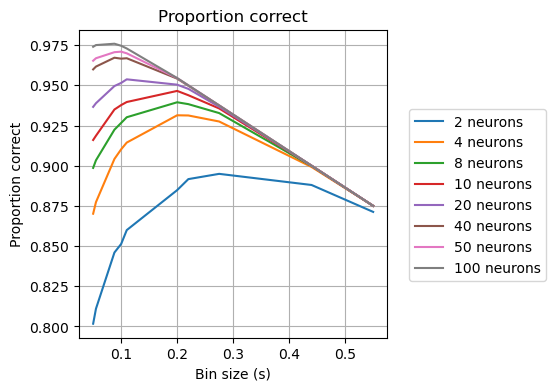

In [19]:
# plot data in proportion correct
fig, axs = plt.subplots(figsize=(6.5, 4))
# axs.plot(bin_sizes_all, chance, 'k--', label='Chance level')

for i in range(len(n_neurons)):
    axs.plot(bin_sizes_all, discrims[i], label=f'{int(n_neurons[i])} neurons')
    axs.set_title('Proportion correct')
    axs.set_xlabel('Bin size (s)')
    axs.set_ylabel('Proportion correct')
    axs.set_box_aspect(1)
    axs.grid(True)
fig.legend(loc='outside right')

plt.show()

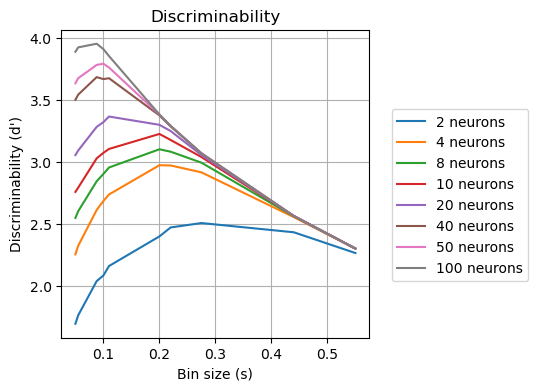

In [20]:
# plot data in d'
X = norm(0, 1)
fig, axs = plt.subplots(figsize=(6.5, 4))
# axs.plot(bin_sizes_all, 2 * X.ppf(chance), 'k--', label='Chance level')

for i in range(len(n_neurons)):
    axs.plot(bin_sizes_all, 2 * X.ppf(discrims[i]), label=f'{int(n_neurons[i])} neurons')
    axs.set_title('Discriminability')
    axs.set_xlabel('Bin size (s)')
    axs.set_ylabel("Discriminability (d')")
    axs.set_box_aspect(1)
    axs.grid(True)
fig.legend(loc='outside right')
plt.show()

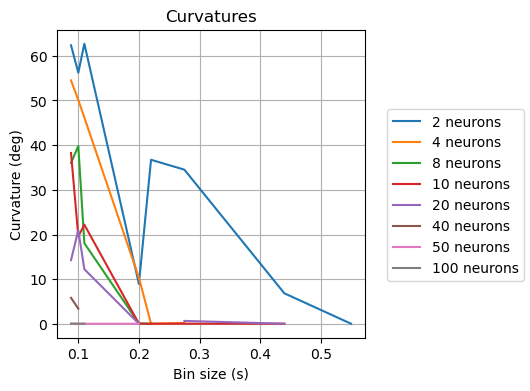

In [21]:
# plot curvature
fig, axs = plt.subplots(figsize=(6.5, 4))

for i in range(len(n_neurons)):
    axs.plot(bin_sizes_all, curvatures[i], label=f'{int(n_neurons[i])} neurons')
    axs.set_title('Curvatures')
    axs.set_xlabel('Bin size (s)')
    axs.set_ylabel('Curvature (deg)')
    axs.set_box_aspect(1)
    axs.grid(True)
fig.legend(loc='outside right')
plt.show()

In [22]:
curvatures

array([[        nan,         nan, 62.32159805, 56.19781876, 62.67354965,
         8.97385883, 36.72446442, 34.51517487,  6.86744499,  0.06992714],
       [        nan,         nan, 54.466259  , 50.09525299, 46.16280365,
        10.37213612,  0.07023559,  0.23575394,         nan,         nan],
       [        nan,         nan, 36.01943207, 39.79788208, 18.06268311,
         0.14390022,  0.06956247,         nan,         nan,         nan],
       [        nan,         nan, 38.24960327, 19.59023857, 22.21106339,
         0.07069268,  0.07026371,  0.0726725 ,  0.07222375,         nan],
       [        nan,         nan, 14.28488159, 20.98771095, 12.25517654,
         0.07160193,         nan,  0.69604778,  0.06946078,         nan],
       [        nan,         nan,  5.85005856,  3.43048191,         nan,
         0.06815089,         nan,         nan,         nan,         nan],
       [        nan,         nan,  0.0914597 ,  0.07111465,  0.07005173,
         0.0700826 ,         nan,         nan